## Clustering to figure out the coordinated Pump and Dump Attempts

In [4]:
df = pd.read_csv("ABSA_Emotion_Aware_nifty50.csv")

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


df = pd.read_csv("ABSA_Emotion_Aware_nifty50.csv")


feature_columns = ['Management', 'Governance', 'Fundamentals', 'Hype', 
                   'Joy', 'Trust', 'Fear', 'Anger', 'Anticipation', 
                   'Disgust', 'Sadness', 'Surprise']


ticker_features = df.groupby('Ticker')[feature_columns].mean().reset_index()
ticker_features.head()


,Ticker,Management,Governance,Fundamentals,Hype,Joy,Trust,Fear,Anger,Anticipation,Disgust,Sadness,Surprise
0,AXISBANK,-0.054406,0.010677,0.003479,-0.000625,0.523750,0.499583,0.429479,0.530313,0.513646,0.513958,0.477917,0.491771
1,HDFC,-0.000248,-0.011475,-0.037356,-0.005911,0.469109,0.471287,0.522475,0.521485,0.513069,0.486238,0.522574,0.497723
2,HINDUNILVR,0.016959,-0.065622,-0.009806,-0.004929,0.504388,0.500102,0.524184,0.496735,0.533061,0.478776,0.463571,0.515816
3,ICICIBANK,-0.005186,0.012147,-0.009892,0.052902,0.502157,0.486667,0.479118,0.512157,0.531078,0.477255,0.495784,0.480294
4,INFY,-0.059971,-0.012365,0.003260,0.002846,0.515769,0.535481,0.558077,0.512596,0.532596,0.487212,0.540962,0.472308


In [7]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(ticker_features[feature_columns])

scaled_features[:5] 


array([[-1.27899529,  0.30268078,  0.33120267, -0.24725808,  1.06172063,
         0.25025902, -1.43954712,  1.56190402,  0.34682612,  0.62331471,
        -0.36184281, -0.35121104],
       [ 0.33228626, -0.35772632, -1.34236905, -0.44486731, -1.72119094,
        -0.97272053,  0.7296906 ,  1.11759823,  0.31977404, -0.5558028 ,
         0.87426015, -0.15178019],
       [ 0.84420473, -1.97196712, -0.21327036, -0.408144  ,  0.07558701,
         0.27267788,  0.76954155, -0.12816276,  1.25784542, -0.87320841,
        -0.75891285,  0.45447821],
       [ 0.18535303,  0.34650381, -0.21679632,  1.75380882, -0.03803401,
        -0.30800734, -0.28167398,  0.648079  ,  1.16480775, -0.93788842,
         0.132726  , -0.73575988],
       [-1.44455729, -0.38426316,  0.32220476, -0.11749149,  0.65525408,
         1.80176851,  1.56013955,  0.67018977,  1.23602313, -0.51437673,
         1.3832122 , -1.00336001]])

## Ticker level Tweets Clustering

In [ ]:
def cluster_users_for_ticker(ticker_df, max_k=6):

    scaler = StandardScaler()
    X = scaler.fit_transform(ticker_df[feature_columns])
    

    inertia = []
    K = range(2, min(max_k, len(ticker_df))+1) 
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)
    
    plt.figure(figsize=(6,3))
    plt.plot(K, inertia, 'bo-')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')
    plt.title(f'Elbow Method: {ticker_df["Ticker"].iloc[0]}')
    plt.show()
    
 
    sil_scores = []
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        if len(set(labels)) > 1:
            sil_scores.append(silhouette_score(X, labels))
        else:
            sil_scores.append(float('nan'))
    
    plt.figure(figsize=(6,3))
    plt.plot(K, sil_scores, 'ro-')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette Score')
    plt.title(f'Silhouette Analysis: {ticker_df["Ticker"].iloc[0]}')
    plt.show()
    

    chosen_k = 3 if len(ticker_df) >= 3 else 2
    kmeans = KMeans(n_clusters=chosen_k, random_state=42)
    ticker_df['Cluster'] = kmeans.fit_predict(X)
    
    return ticker_df


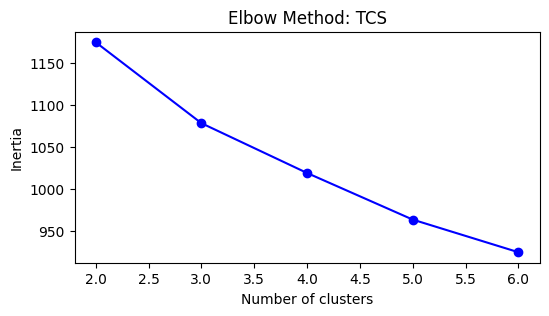

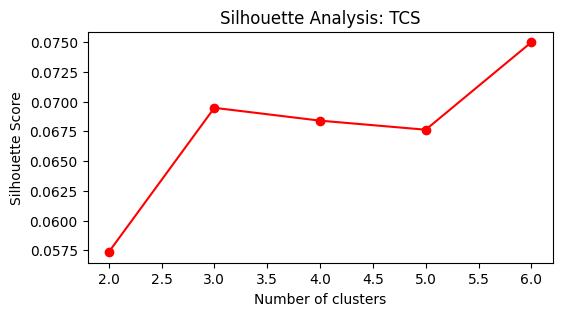

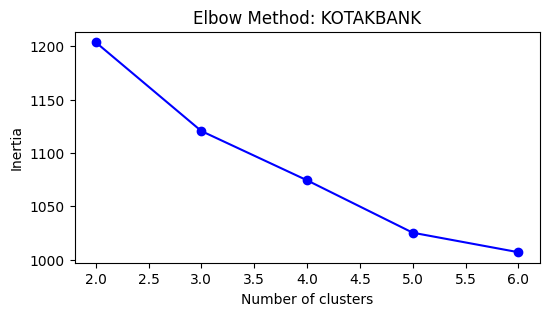

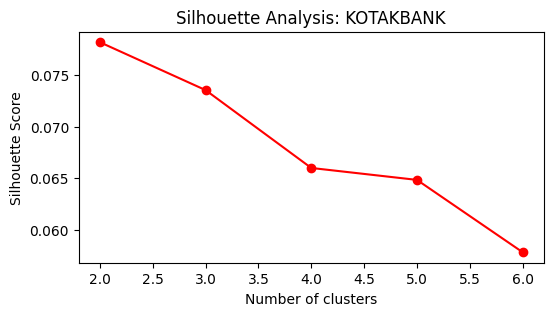

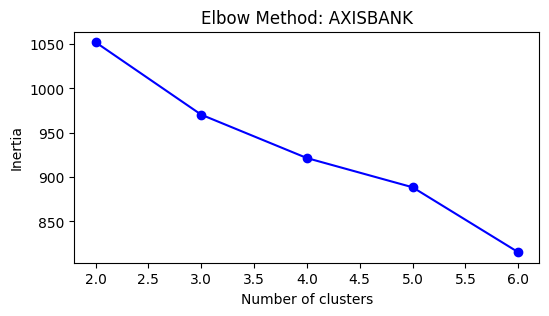

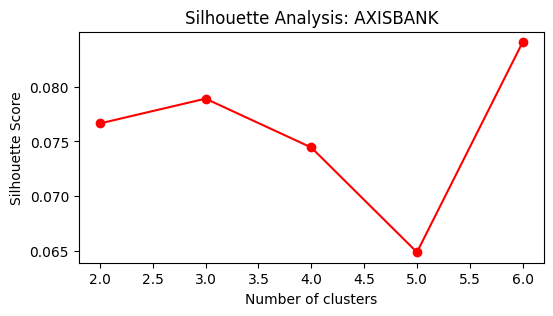

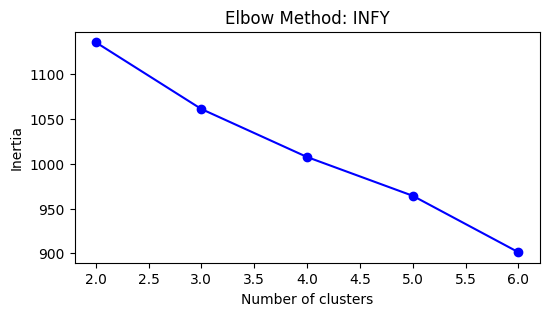

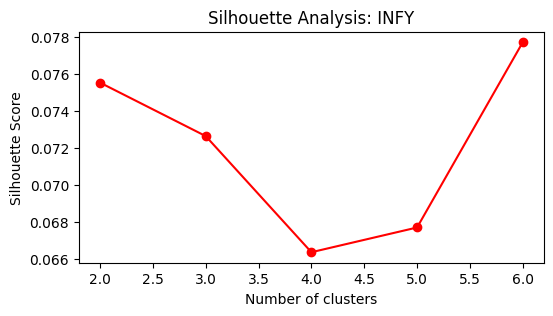

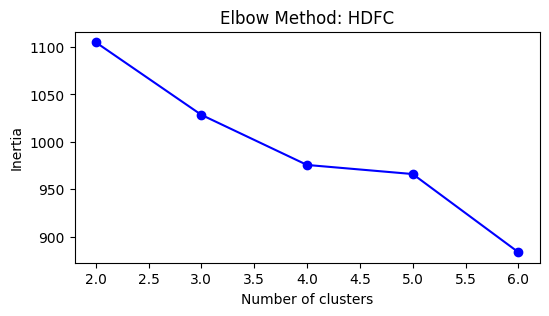

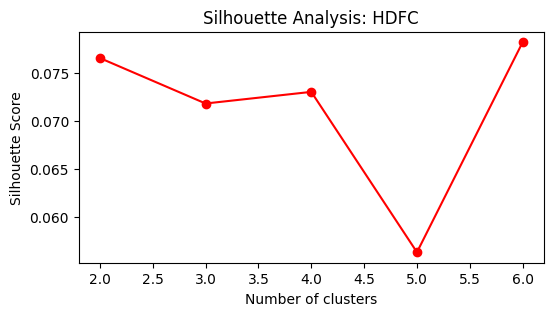

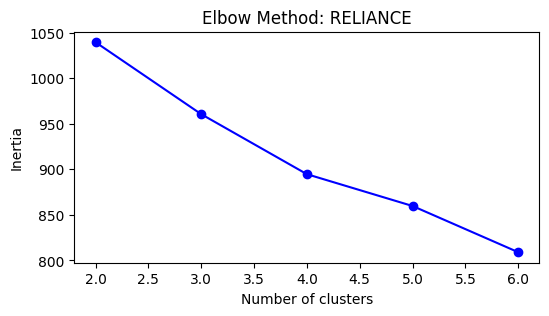

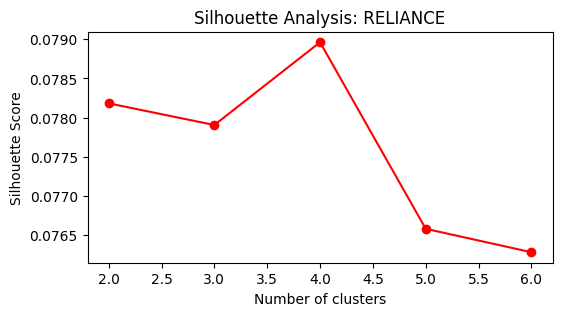

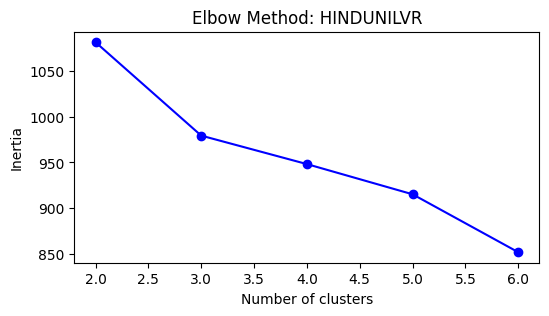

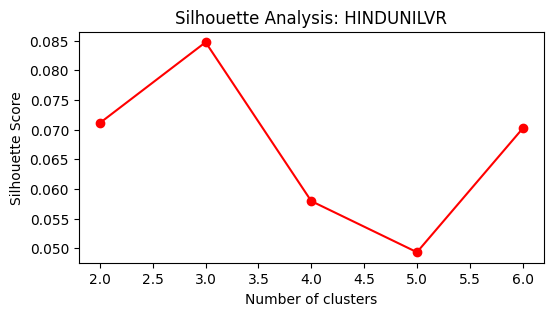

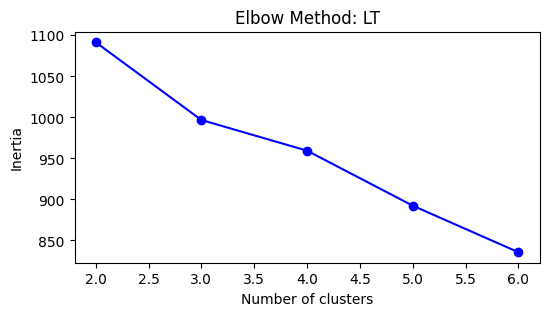

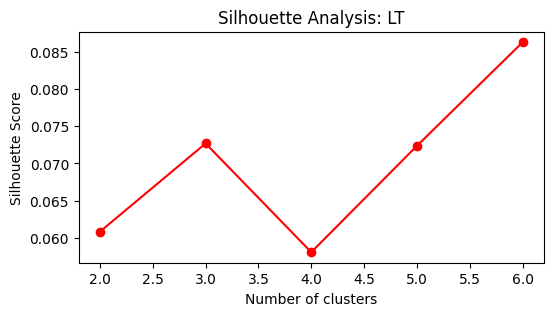

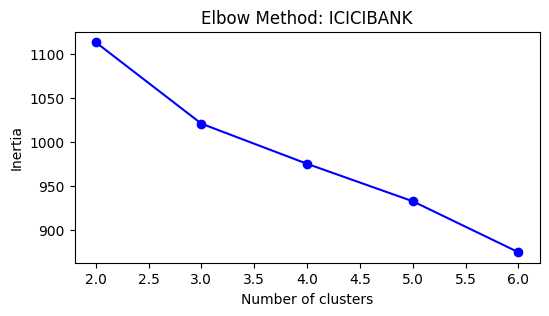

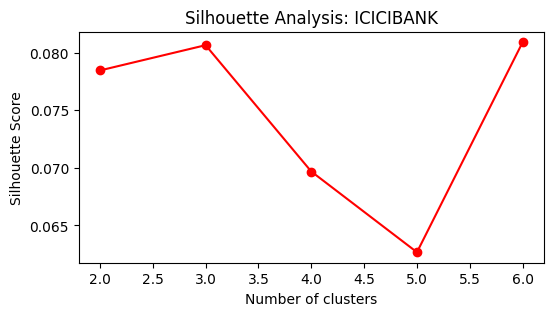

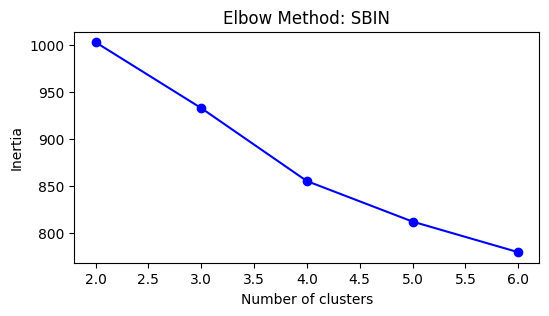

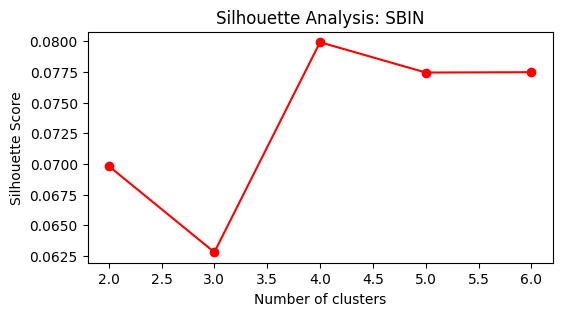

,User,Ticker,Tweet,Management,Governance,Fundamentals,Hype,Joy,Trust,Fear,Anger,Anticipation,Disgust,Sadness,Surprise,Cluster
0,@user0,TCS,TCS is showing strong growth this quarter.,0.054,0.306,0.104,-0.260,0.06,0.72,0.20,0.41,0.56,0.38,0.47,0.93,0
1,@user1,TCS,TCS is showing strong growth this quarter.,0.063,-0.028,0.458,0.066,0.25,0.60,0.99,0.01,0.98,0.96,0.41,0.01,1
25,@user25,TCS,TCS might face regulatory challenges.,0.162,0.459,0.430,-0.069,0.15,0.33,0.11,0.15,0.25,0.42,0.47,0.28,0
28,@user28,TCS,Market hype around TCS is high.,-0.332,0.231,0.340,-0.425,0.09,0.69,0.71,0.09,0.69,0.73,0.69,0.66,0
30,@user30,TCS,Concerns over TCS's management decisions.,0.175,0.165,0.161,0.366,0.83,0.00,0.42,0.79,0.08,0.04,0.13,0.14,1


In [13]:
clustered_users = pd.DataFrame()

for ticker in df['Ticker'].unique():
    ticker_df = df[df['Ticker']==ticker].copy()
    clustered_ticker_df = cluster_users_for_ticker(ticker_df)
    clustered_users = pd.concat([clustered_users, clustered_ticker_df])

clustered_users.head()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_radar_clusters(ticker_df, feature_cols, title=""):
    """
    ticker_df: DataFrame containing 'Cluster' and features
    feature_cols: list of features to plot
    title: plot title
    """
    if 'Cluster' not in ticker_df.columns or ticker_df.empty:
        print(f"No data or clusters available for {title}")
        return
    
    clusters = ticker_df['Cluster'].unique()
    if len(clusters) == 0:
        print(f"No clusters found for {title}")
        return
    
    N = len(feature_cols)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1] 
    

    n_subplots = max(len(clusters), 1)
    fig, axes = plt.subplots(1, n_subplots, subplot_kw=dict(polar=True), figsize=(5*n_subplots,5))
    
    if n_subplots == 1:
        axes = [axes]
    
    for ax, cluster in zip(axes, clusters):
        cluster_data = ticker_df[ticker_df['Cluster']==cluster][feature_cols].mean().tolist()
        cluster_data += cluster_data[:1]  
        
        ax.plot(angles, cluster_data, linewidth=2, label=f'Cluster {cluster}')
        ax.fill(angles, cluster_data, alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(feature_cols, rotation=45, fontsize=10)
        ax.set_title(f'Cluster {cluster}', size=12, y=1.1)
        ax.set_yticklabels([])  
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


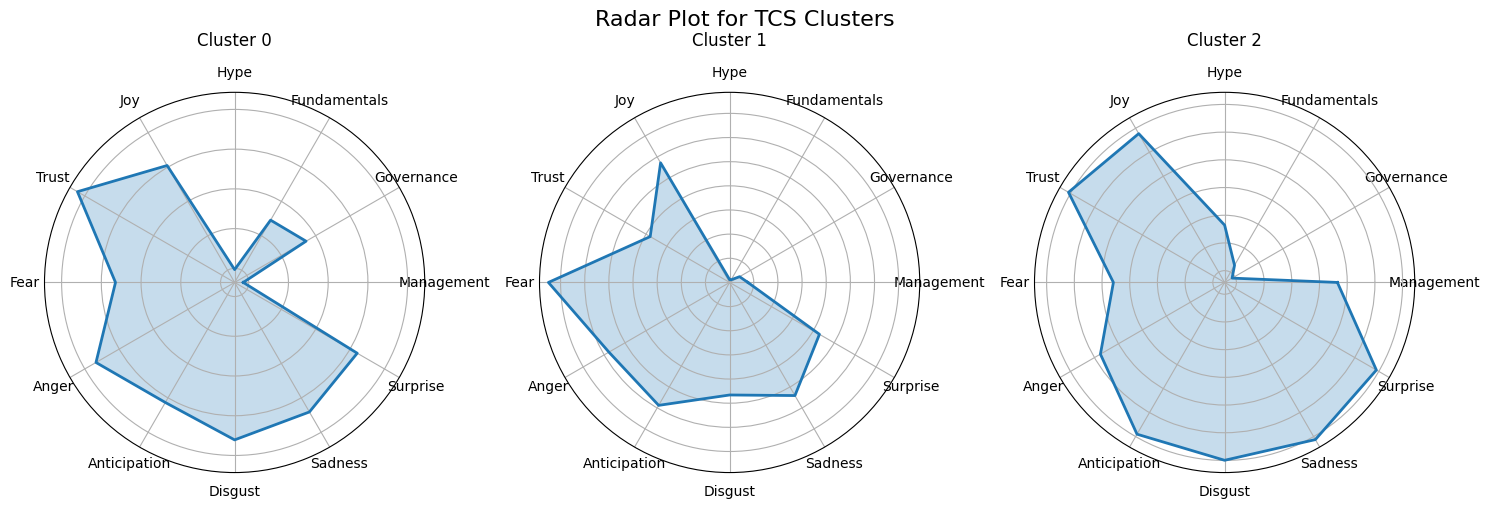

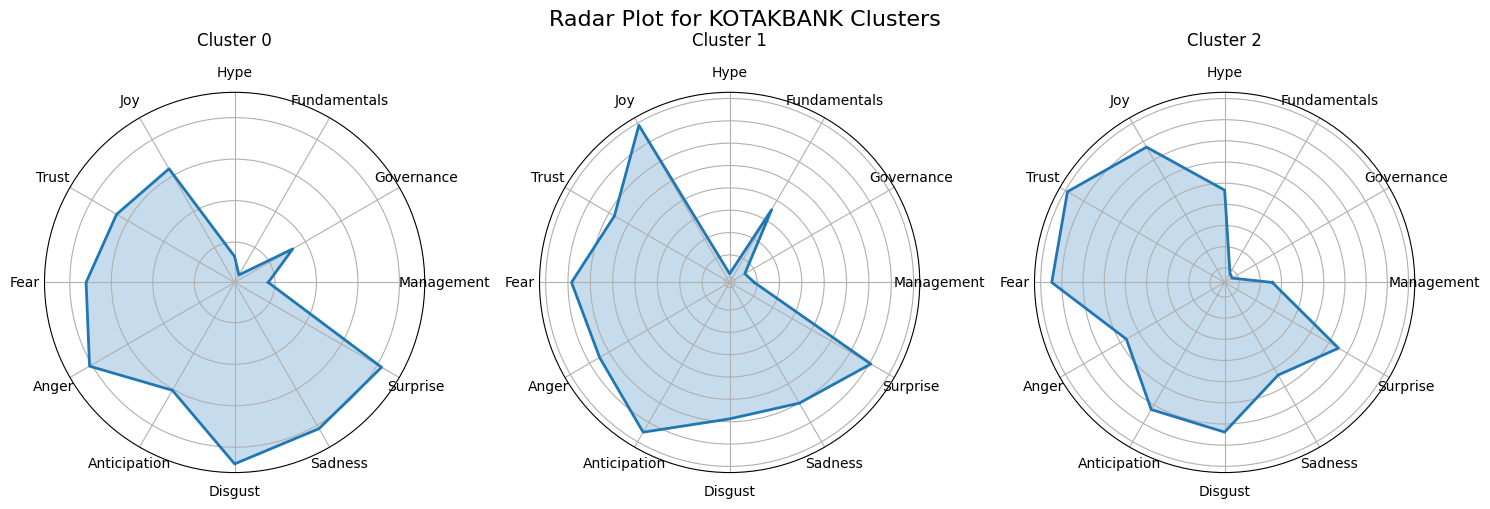

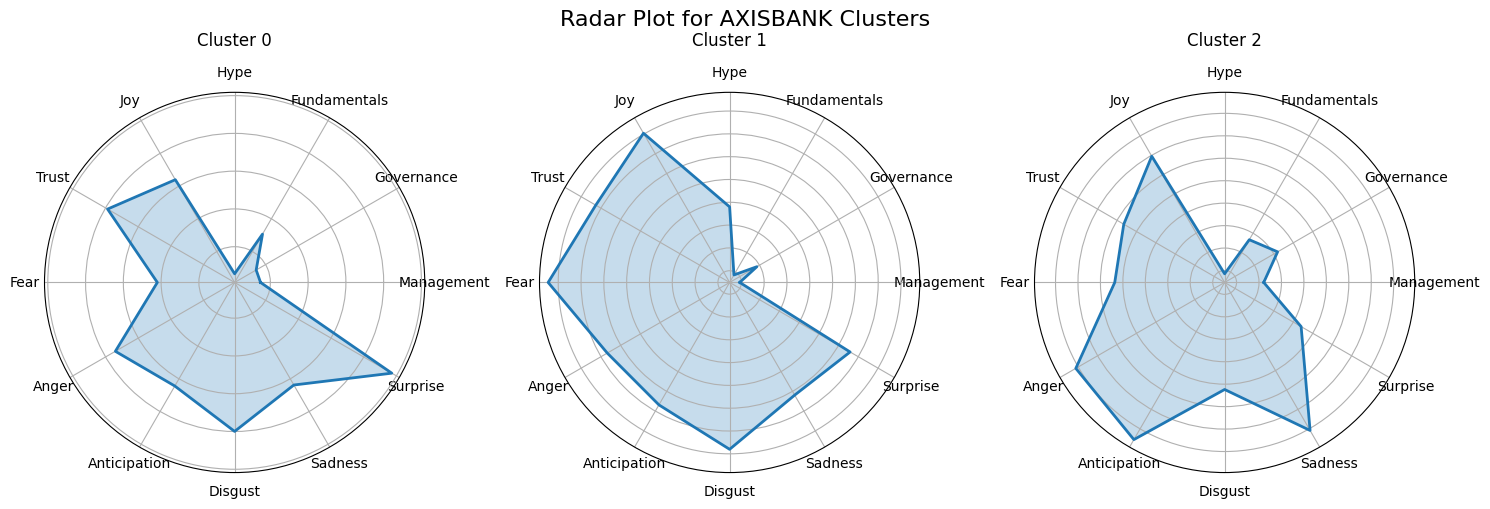

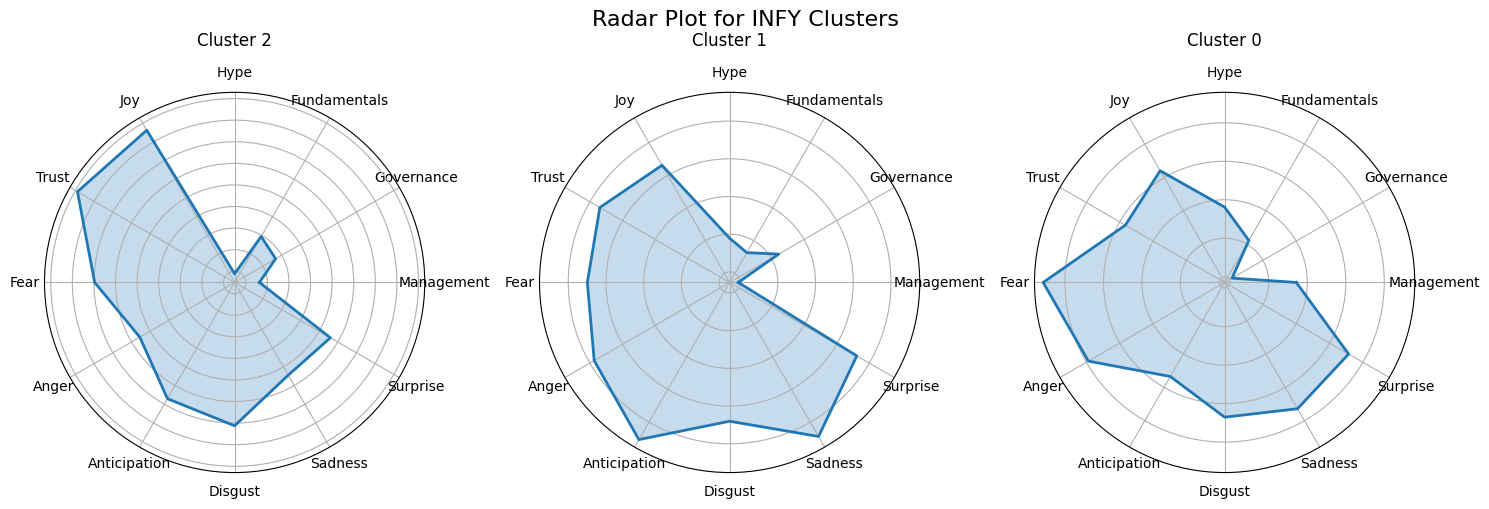

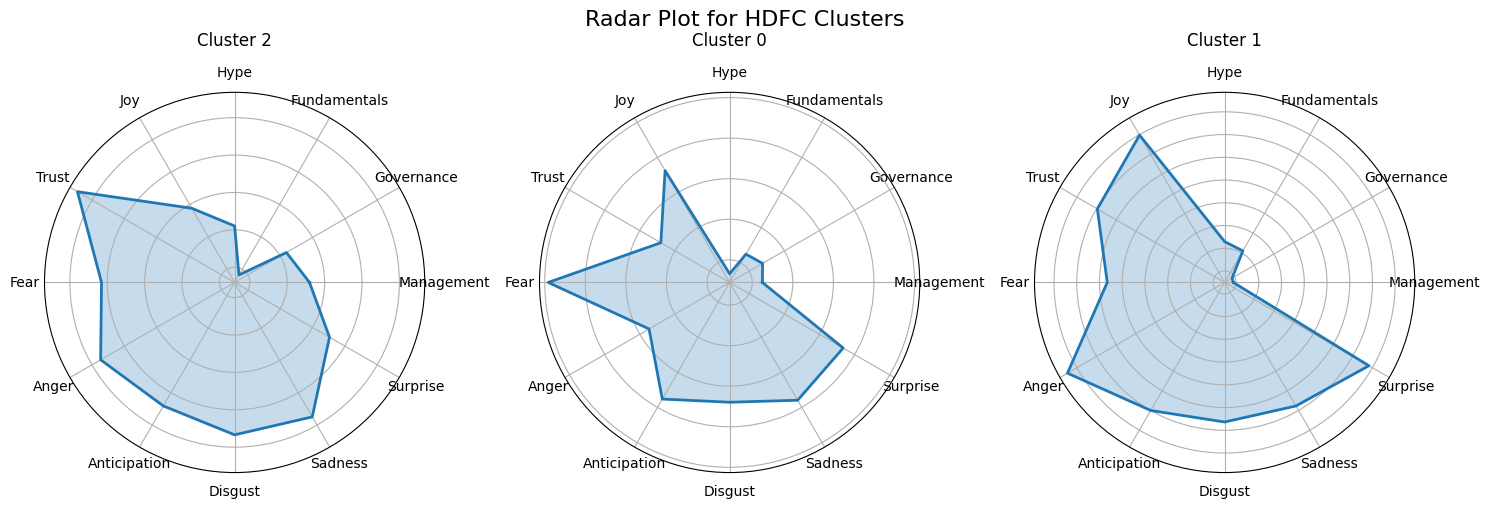

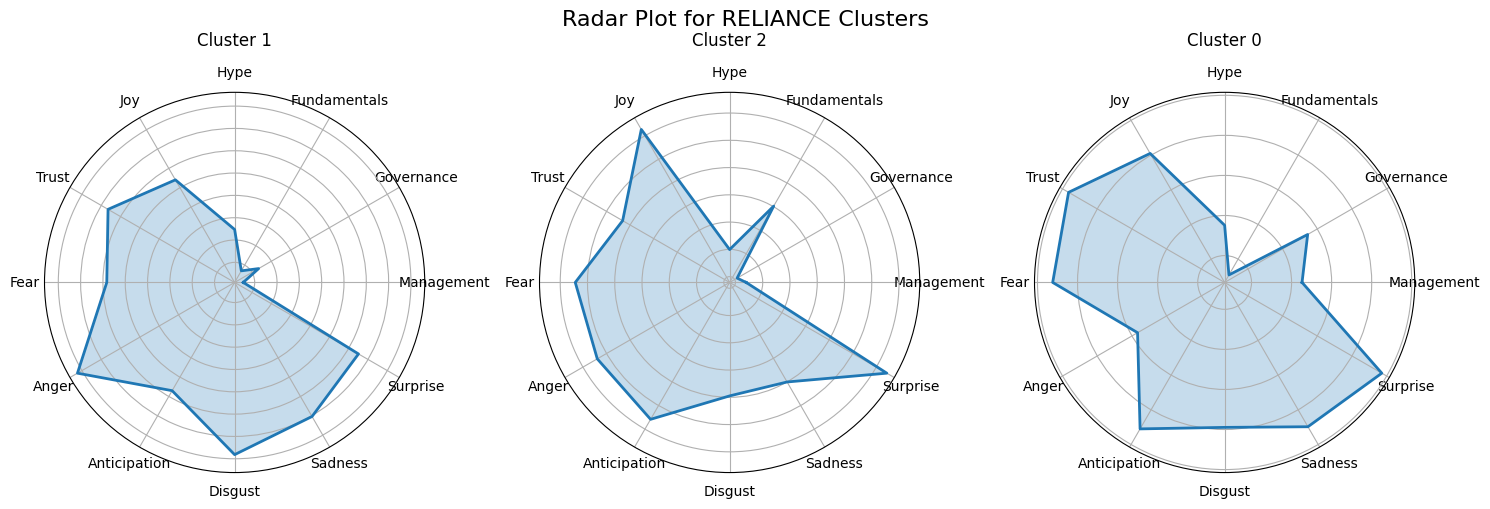

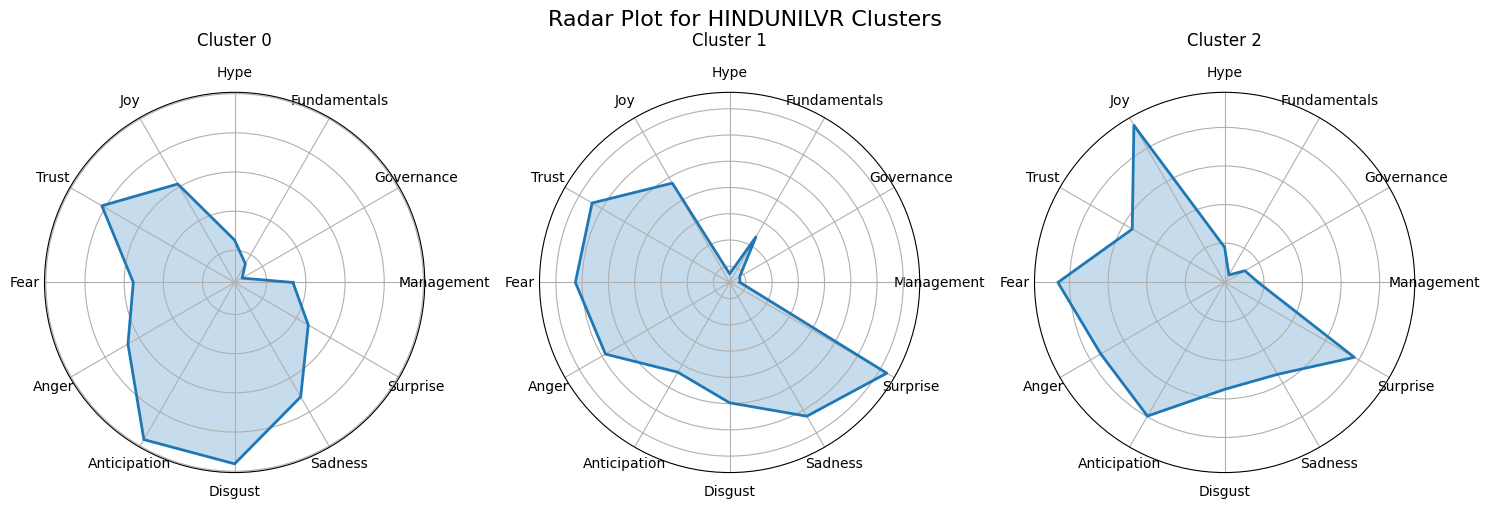

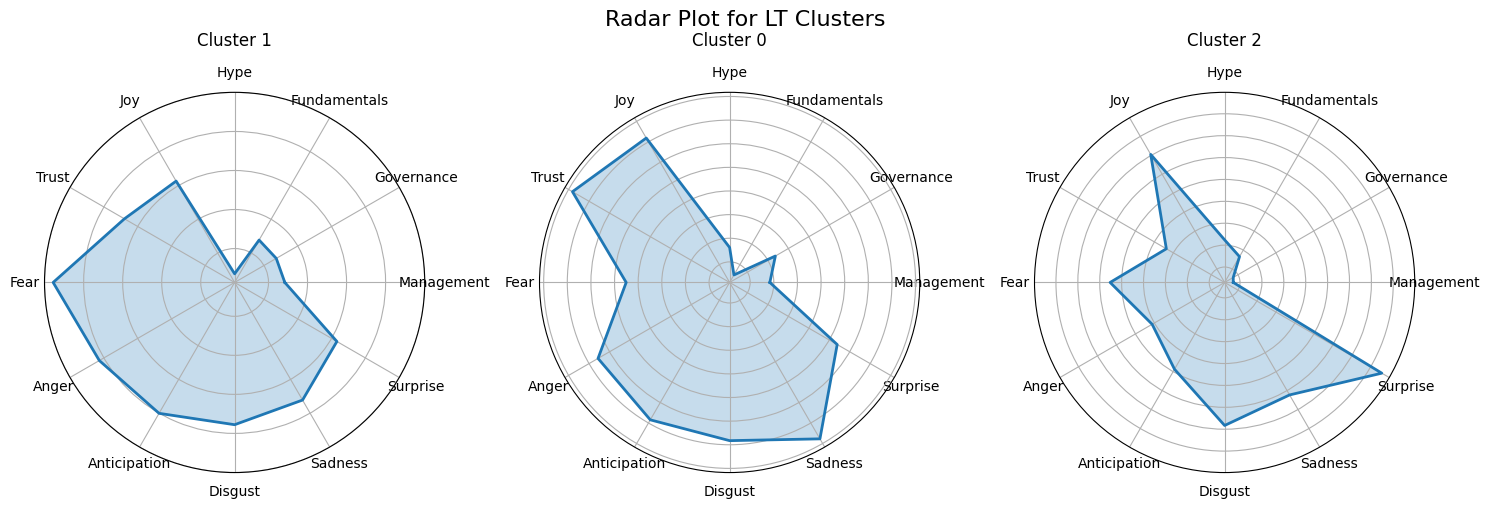

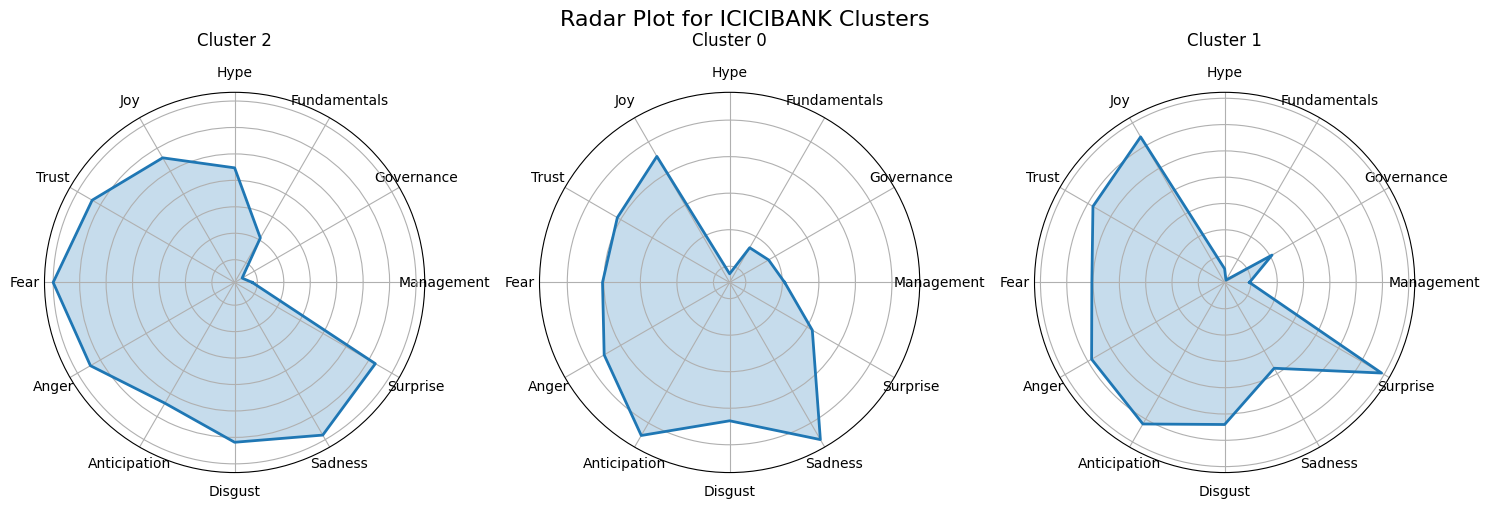

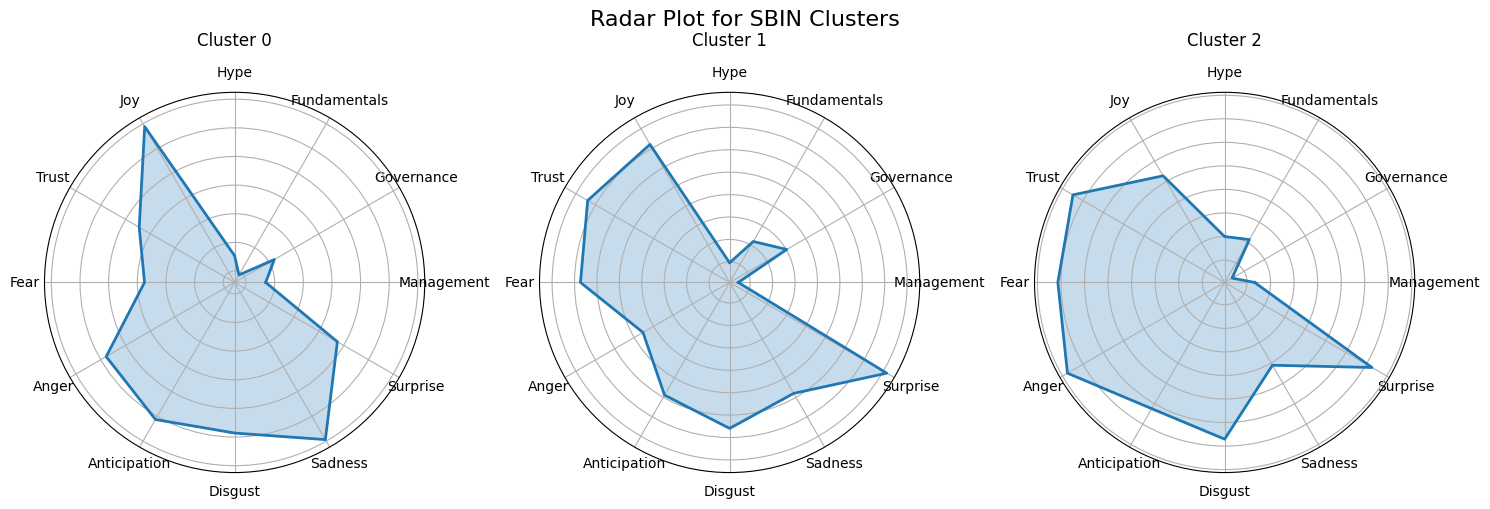

In [20]:
for ticker in clustered_users['Ticker'].unique():
    ticker_df = clustered_users[clustered_users['Ticker']==ticker]
    plot_radar_clusters(ticker_df, feature_columns, title=f'Radar Plot for {ticker} Clusters')


## This step helps to detect the coordinated attemps of Pump and Dump for at Ticker Level